# Panel cumulative local projections: CPI on xi x oil

This notebook estimates cumulative panel local projections using quarterly CPI inflation.

Conventions used here:

- the dependent variable at horizon `h` is the cumulative sum of quarterly CPI inflation from `t` through `t+h`,
- lags of `y` are lags of the underlying quarterly CPI inflation series, not lags of the cumulative target,
- if enabled, annual CPI can replace the cumulative quarterly target only for full calendar-year windows.


In [25]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import local_projections as lp


In [26]:
xi_path = ROOT / "data/processed/xi/regular/xi_by_country_year.parquet"
cpi_path = ROOT / "data/processed/cpi/quarterly_cpi.csv"
annual_cpi_path = ROOT / "data/processed/cpi/annual_cpi.csv"
oil_path = ROOT / "data/processed/oil/quarterly_oil.csv"
cpi_freq = "Q"

panel_controls = [
    {
        "name": "exchange_rate",
        "path": ROOT / "data/processed/exchange_rates/quarterly_exchange_rates.csv",
        "value_column": "log_diff",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"country": "country_code", "period": "quarter"},
        "status_column": None,
    },
    {
        "name": "output_gap",
        "path": ROOT / "data/processed/real_gdp/quarterly_output_gap.csv",
        "value_column": "output_gap",
        "merge_keys": ["country", "period"],
        "status_column": "hp_filter_status",
        "ok_status": "ok",
    },
    {
        "name": "policy_rate",
        "path": ROOT / "data/processed/policy_rates/quarterly_policy_rates.csv",
        "value_column": "policy_rate",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"period": "quarter"},
        "status_column": None,
    },
    {
        "name": "c_diff",
        "path": ROOT / "data/processed/c_diff/regular/c_diff_quarterly_by_country_period.parquet",
        "value_column": "c_diff",
        "merge_keys": ["country", "period"],
        "status_column": "status",
        "ok_status": "ok",
        "required_for_sample": False,
    },
]
base_regression_controls = ["exchange_rate", "output_gap", "policy_rate"]
include_c_diff_control = False
lag_c_diff_by_one_year_for_controls = True
include_contemporaneous_c_diff_control = True
include_contemporaneous_oil_control = False
c_diff_control_name = "c_diff_control"

regression_controls = base_regression_controls.copy()
if include_c_diff_control:
    regression_controls.append(c_diff_control_name)
if "oil_pct_change" not in regression_controls and include_contemporaneous_oil_control:
    regression_controls.append("oil_pct_change")
#regression_controls = ["oil_pct_change", "exchange_rate"]
contemporaneous_controls = []
if include_c_diff_control and include_contemporaneous_c_diff_control:
    contemporaneous_controls.append(c_diff_control_name)
if include_contemporaneous_oil_control:
    contemporaneous_controls.append("oil_pct_change")

horizons = 11
y_lags = 3
shock_lags = 3
control_lags = {"exchange_rate": 3, "output_gap": 3, "policy_rate": 3}
if "oil_pct_change" in regression_controls:
    control_lags["oil_pct_change"] = 3
if include_c_diff_control:
    control_lags[c_diff_control_name] = 3
include_country_fe = True
include_time_fe = True
cov_type = "cluster_country_time"
common_sample = True
remove_cpi_outliers = False
iqr_multiplier = 10
exclude_countries = []
sample_start = None
sample_end = None
use_annual_cpi_for_full_year_horizons = False
lag_xi_by_one_year_for_xi_x_oil = True

print("horizons:", horizons)
print("y_lags:", y_lags)
print("shock_lags:", shock_lags)
print("control_lags:", control_lags)
print("include_country_fe:", include_country_fe)
print("include_time_fe:", include_time_fe)
print("cov_type:", cov_type)
print("common_sample:", common_sample)
print("remove_cpi_outliers:", remove_cpi_outliers)
print("iqr_multiplier:", iqr_multiplier)
print("panel_controls:", [spec["name"] for spec in panel_controls])
print("regression_controls:", regression_controls)
print("include_c_diff_control:", include_c_diff_control)
print("lag_c_diff_by_one_year_for_controls:", lag_c_diff_by_one_year_for_controls)
print("include_contemporaneous_c_diff_control:", include_contemporaneous_c_diff_control)
print("include_contemporaneous_oil_control:", include_contemporaneous_oil_control)
print("contemporaneous_controls:", contemporaneous_controls)
print("use_annual_cpi_for_full_year_horizons:", use_annual_cpi_for_full_year_horizons)
print("lag_xi_by_one_year_for_xi_x_oil:", lag_xi_by_one_year_for_xi_x_oil)


horizons: 11
y_lags: 3
shock_lags: 3
control_lags: {'exchange_rate': 3, 'output_gap': 3, 'policy_rate': 3}
include_country_fe: True
include_time_fe: True
cov_type: cluster_country_time
common_sample: True
remove_cpi_outliers: False
iqr_multiplier: 10
panel_controls: ['exchange_rate', 'output_gap', 'policy_rate', 'c_diff']
regression_controls: ['exchange_rate', 'output_gap', 'policy_rate']
include_c_diff_control: False
lag_c_diff_by_one_year_for_controls: True
include_contemporaneous_c_diff_control: True
include_contemporaneous_oil_control: False
contemporaneous_controls: []
use_annual_cpi_for_full_year_horizons: False
lag_xi_by_one_year_for_xi_x_oil: True


In [27]:
def load_annual_cpi(path: Path) -> pd.DataFrame:
    annual = lp.regression.load_cpi_pct_change(path, freq="A")
    annual = annual.rename(columns={"cpi_pct_change": "annual_cpi_pct_change"})
    return annual


def add_cumulative_targets(
    df: pd.DataFrame,
    *,
    y_col: str = "cpi_pct_change",
    horizons: int = 8,
    annual_cpi_df: pd.DataFrame | None = None,
    use_annual_override: bool = False,
) -> pd.DataFrame:
    out = df.copy().sort_values(["country", "time_index"]).reset_index(drop=True)
    if "period" not in out.columns:
        raise ValueError("Quarterly cumulative LP requires a 'period' column.")

    period_parts = out["period"].astype(str).str.extract(r"^(\d{4})-Q([1-4])$")
    out["period_year"] = pd.to_numeric(period_parts[0], errors="coerce")
    out["period_quarter"] = pd.to_numeric(period_parts[1], errors="coerce")
    if out[["period_year", "period_quarter"]].isna().any().any():
        raise ValueError("Could not parse year/quarter from the quarterly period labels.")
    out["period_year"] = out["period_year"].astype(int)
    out["period_quarter"] = out["period_quarter"].astype(int)

    if annual_cpi_df is not None:
        annual_lookup = annual_cpi_df.copy()
    else:
        annual_lookup = None

    for horizon in range(horizons + 1):
        target_col = f"cum_cpi_lead{horizon}"
        out[target_col] = 0.0
        for step in range(horizon + 1):
            shifted = out.groupby("country")[y_col].shift(-step)
            out[target_col] = shifted if step == 0 else out[target_col] + shifted

        if use_annual_override and annual_lookup is not None and (horizon + 1) % 4 == 0:
            end_year_col = f"end_year_h{horizon}"
            end_quarter_col = f"end_quarter_h{horizon}"
            out[end_year_col] = out.groupby("country")["period_year"].shift(-horizon)
            out[end_quarter_col] = out.groupby("country")["period_quarter"].shift(-horizon)
            aligned = (out["period_quarter"] == 1) & (out[end_quarter_col] == 4)
            annual_rows = []
            years_in_window = (horizon + 1) // 4
            for year_offset in range(years_in_window):
                year_col = f"annual_year_h{horizon}_{year_offset}"
                value_col = f"annual_cpi_h{horizon}_{year_offset}"
                out[year_col] = out["period_year"] + year_offset
                merged = out[["country", year_col]].merge(
                    annual_lookup,
                    left_on=["country", year_col],
                    right_on=["country", "year"],
                    how="left",
                )
                out[value_col] = merged["annual_cpi_pct_change"].values
                annual_rows.append(value_col)
            annual_sum = out[annual_rows].sum(axis=1, min_count=years_in_window)
            out[target_col] = out[target_col].where(~aligned, annual_sum)

    return out


def fit_cumulative_panel_local_projections(
    df: pd.DataFrame,
    *,
    y_col: str = "cpi_pct_change",
    shock_col: str = "xi_x_oil",
    horizons: int = 8,
    y_lags: int = 4,
    shock_lags: int = 0,
    controls: list[str] | None = None,
    control_lags: int | dict[str, int] = 0,
    include_country_fe: bool = True,
    include_time_fe: bool = True,
    cov_type: str = "cluster_country",
) -> tuple[pd.DataFrame, pd.DataFrame, dict[int, object]]:
    controls = controls or []
    required = {"country", "time_index", y_col, shock_col, *controls}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing cumulative LP columns: {sorted(missing)}")

    target_cols = [f"cum_cpi_lead{h}" for h in range(horizons + 1)]
    missing_targets = sorted(set(target_cols) - set(df.columns))
    if missing_targets:
        raise ValueError(f"Missing cumulative target columns: {missing_targets}")

    work = df[["country", "time_index", "year", "period", y_col, shock_col, *controls, *target_cols]].copy()
    work = work.sort_values(["country", "time_index"]).reset_index(drop=True)

    y_lag_cols = []
    for lag in range(1, y_lags + 1):
        col = f"{y_col}_lag{lag}"
        work[col] = work.groupby("country")[y_col].shift(lag)
        y_lag_cols.append(col)

    shock_lag_cols = []
    for lag in range(1, shock_lags + 1):
        col = f"{shock_col}_lag{lag}"
        work[col] = work.groupby("country")[shock_col].shift(lag)
        shock_lag_cols.append(col)

    control_cols = []
    for control in controls:
        lag_count = control_lags[control] if isinstance(control_lags, dict) else int(control_lags)
        for lag in range(1, lag_count + 1):
            col = f"{control}_lag{lag}"
            work[col] = work.groupby("country")[control].shift(lag)
            control_cols.append(col)

    irf_rows = []
    coef_rows = []
    models = {}

    for horizon in range(horizons + 1):
        dep_col = f"cum_cpi_lead{horizon}"

        x_cols = [shock_col, *shock_lag_cols, *y_lag_cols, *control_cols]
        x_base = work[x_cols].copy()
        fe_cols = []

        if include_country_fe:
            country_fe = pd.get_dummies(work["country"], prefix="country_fe", drop_first=True, dtype=float)
            x_base = pd.concat([x_base, country_fe], axis=1)
            fe_cols.extend(country_fe.columns.tolist())

        if include_time_fe:
            time_fe = pd.get_dummies(work["time_index"], prefix="time_fe", drop_first=True, dtype=float)
            x_base = pd.concat([x_base, time_fe], axis=1)
            fe_cols.extend(time_fe.columns.tolist())

        design = pd.concat([work[["country", "year", "period", dep_col]], x_base], axis=1).dropna().reset_index(drop=True)
        if design.empty:
            raise ValueError(
                "No rows left for cumulative local projections after target, lag, and missing-data filters. "
                f"horizon={horizon}, y_lags={y_lags}, shock_lags={shock_lags}."
            )

        y = pd.to_numeric(design[dep_col], errors="coerce")
        x = sm.add_constant(design[x_cols + fe_cols], has_constant="add")
        base_model = sm.OLS(y, x, missing="raise")
        if cov_type == "cluster_country":
            model = base_model.fit(cov_type="cluster", cov_kwds={"groups": design["country"]})
            std_err_col = "std_err_cluster_country"
        elif cov_type == "hc3":
            model = base_model.fit(cov_type="HC3")
            std_err_col = "std_err_hc3"
        else:
            raise ValueError(f"Unsupported cov_type '{cov_type}'.")

        models[horizon] = model
        ci = model.conf_int()
        coef_df = pd.DataFrame(
            {
                "horizon": horizon,
                "term": model.params.index,
                "coef": model.params.values,
                std_err_col: model.bse.values,
                "t": model.tvalues.values,
                "p_value": model.pvalues.values,
                "ci_low_95": ci.iloc[:, 0].values,
                "ci_high_95": ci.iloc[:, 1].values,
                "nobs": float(model.nobs),
            }
        )
        coef_rows.extend(coef_df.to_dict(orient="records"))

        shock_row = coef_df.loc[coef_df["term"] == shock_col]
        irf_rows.append(
            {
                "horizon": horizon,
                "term": shock_col,
                "coef": float(shock_row["coef"].iloc[0]),
                std_err_col: float(shock_row[std_err_col].iloc[0]),
                "t": float(shock_row["t"].iloc[0]),
                "p_value": float(shock_row["p_value"].iloc[0]),
                "ci_low_95": float(shock_row["ci_low_95"].iloc[0]),
                "ci_high_95": float(shock_row["ci_high_95"].iloc[0]),
                "nobs": float(model.nobs),
                "n_countries": int(design["country"].nunique()),
            }
        )

    return pd.DataFrame(irf_rows), pd.DataFrame(coef_rows), models


In [28]:
panel_df = lp.build_panel_lp_dataset(
    xi_path=xi_path,
    cpi_path=cpi_path,
    oil_path=oil_path,
    cpi_freq=cpi_freq,
    lag_xi_by_one_year_for_xi_x_oil=lag_xi_by_one_year_for_xi_x_oil,
    controls=panel_controls,
    exclude_countries=exclude_countries,
    sample_start=sample_start,
    sample_end=sample_end,
)

if include_c_diff_control:
    c_diff_shift = 4 if lag_c_diff_by_one_year_for_controls else 0
    if c_diff_shift == 0:
        panel_df[c_diff_control_name] = panel_df["c_diff"]
    else:
        panel_df[c_diff_control_name] = panel_df.groupby("country")["c_diff"].shift(c_diff_shift)

diag_df = lp.panel_diagnostics(panel_df)
diag_df


,rows,countries,year_min,year_max,avg_years_per_country,period_min,period_max,avg_periods_per_country
0,7522,80,1995,2022,23.625,1995-Q1,2022-Q4,94.025


In [29]:
panel_df_model = panel_df.copy()

if remove_cpi_outliers:
    q1 = panel_df_model["cpi_pct_change"].quantile(0.25)
    q3 = panel_df_model["cpi_pct_change"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_multiplier * iqr
    upper = q3 + iqr_multiplier * iqr
    panel_df_model = panel_df_model.loc[
        panel_df_model["cpi_pct_change"].between(lower, upper)
    ].copy()
    print(f"CPI IQR fence: [{lower:.6f}, {upper:.6f}]")
    print("Rows after CPI outlier filter:", len(panel_df_model))
    print("Dropped rows:", len(panel_df) - len(panel_df_model))
else:
    print("CPI outlier filter disabled.")
    print("Rows kept:", len(panel_df_model))

annual_cpi_df = load_annual_cpi(annual_cpi_path)
panel_df_model = lp.build_cumulative_targets(
    panel_df_model,
    y_col="cpi_pct_change",
    horizons=horizons,
    annual_cpi_df=annual_cpi_df,
    use_annual_override=use_annual_cpi_for_full_year_horizons,
)

panel_df_model.head()


CPI outlier filter disabled.
Rows kept: 7522


,country,year,period,time_index,xi,oil_pct_change,xi_x_oil,cpi_pct_change,xi_amp_1,xi_amp_2,...,cum_cpi_lead2,cum_cpi_lead3,cum_cpi_lead4,cum_cpi_lead5,cum_cpi_lead6,cum_cpi_lead7,cum_cpi_lead8,cum_cpi_lead9,cum_cpi_lead10,cum_cpi_lead11
0,AGO,2002,2002-Q2,8009,0.085897,0.189848,0.007227,0.171750,0.010059,0.008580,...,0.560691,0.794783,0.995316,1.136748,1.219820,1.318576,1.405436,1.464548,1.517118,1.579593
1,AGO,2002,2002-Q3,8010,0.085897,0.066242,0.002522,0.209522,0.010059,0.008580,...,0.623033,0.823566,0.964998,1.048071,1.146827,1.233687,1.292798,1.345368,1.407844,1.454514
2,AGO,2002,2002-Q4,8011,0.085897,-0.011465,-0.000436,0.179419,0.010059,0.008580,...,0.614044,0.755476,0.838549,0.937305,1.024164,1.083276,1.135846,1.198321,1.244992,1.279011
3,AGO,2003,2003-Q1,8012,0.107717,0.162677,0.013974,0.234092,0.016459,0.012144,...,0.576057,0.659129,0.757885,0.844745,0.903857,0.956426,1.018902,1.065572,1.099592,1.135296
4,AGO,2003,2003-Q2,8013,0.107717,-0.167036,-0.014348,0.200532,0.016459,0.012144,...,0.425037,0.523793,0.610653,0.669765,0.722334,0.784810,0.831481,0.865500,0.901204,0.933960


In [30]:
cum_cols = [f"cum_cpi_lead{h}" for h in range(horizons + 1)]
panel_df_model[["country", "period", "cpi_pct_change", *cum_cols]].head(12)


,country,period,cpi_pct_change,cum_cpi_lead0,cum_cpi_lead1,cum_cpi_lead2,cum_cpi_lead3,cum_cpi_lead4,cum_cpi_lead5,cum_cpi_lead6,cum_cpi_lead7,cum_cpi_lead8,cum_cpi_lead9,cum_cpi_lead10,cum_cpi_lead11
0,AGO,2002-Q2,0.171750,0.171750,0.381272,0.560691,0.794783,0.995316,1.136748,1.219820,1.318576,1.405436,1.464548,1.517118,1.579593
1,AGO,2002-Q3,0.209522,0.209522,0.388942,0.623033,0.823566,0.964998,1.048071,1.146827,1.233687,1.292798,1.345368,1.407844,1.454514
2,AGO,2002-Q4,0.179419,0.179419,0.413511,0.614044,0.755476,0.838549,0.937305,1.024164,1.083276,1.135846,1.198321,1.244992,1.279011
3,AGO,2003-Q1,0.234092,0.234092,0.434624,0.576057,0.659129,0.757885,0.844745,0.903857,0.956426,1.018902,1.065572,1.099592,1.135296
4,AGO,2003-Q2,0.200532,0.200532,0.341965,0.425037,0.523793,0.610653,0.669765,0.722334,0.784810,0.831481,0.865500,0.901204,0.933960
5,AGO,2003-Q3,0.141433,0.141433,0.224505,0.323261,0.410121,0.469233,0.521802,0.584278,0.630948,0.664968,0.700671,0.733427,0.757690
6,AGO,2003-Q4,0.083072,0.083072,0.181828,0.268688,0.327800,0.380369,0.442845,0.489516,0.523535,0.559239,0.591995,0.616258,0.641487
7,AGO,2004-Q1,0.098756,0.098756,0.185616,0.244728,0.297297,0.359773,0.406443,0.440463,0.476166,0.508922,0.533185,0.558414,0.591883
8,AGO,2004-Q2,0.086860,0.086860,0.145972,0.198541,0.261017,0.307687,0.341707,0.377410,0.410166,0.434429,0.459659,0.493127,0.527933
9,AGO,2004-Q3,0.059112,0.059112,0.111681,0.174157,0.220827,0.254847,0.290550,0.323306,0.347569,0.372799,0.406267,0.441073,0.465827


In [31]:
irf_df, coef_df, models = lp.fit_cumulative_panel_local_projections(
    panel_df_model,
    y_col="cpi_pct_change",
    shock_col="xi_x_oil",
    horizons=horizons,
    y_lags=y_lags,
    shock_lags=shock_lags,
    controls=regression_controls,
    control_lags=control_lags,
    include_contemporaneous_controls=contemporaneous_controls or False,
    include_country_fe=include_country_fe,
    include_time_fe=include_time_fe,
    cov_type=cov_type,
    common_sample=common_sample,
)

irf_df


,horizon,term,coef,std_err_cluster_country_time,t,p_value,ci_low_95,ci_high_95,nobs,n_countries
0,0,xi_x_oil,-0.086147,0.046211,-1.864210,0.062292,-0.176720,0.004425,3531.0,50
1,1,xi_x_oil,-0.072473,0.061303,-1.182211,0.237122,-0.192624,0.047678,3531.0,50
2,2,xi_x_oil,-0.099026,0.075881,-1.305012,0.191889,-0.247750,0.049698,3531.0,50
3,3,xi_x_oil,-0.119602,0.081246,-1.472104,0.140993,-0.278841,0.039637,3531.0,50
4,4,xi_x_oil,-0.192344,0.087782,-2.191163,0.028440,-0.364394,-0.020295,3531.0,50
5,5,xi_x_oil,-0.184670,0.101897,-1.812324,0.069936,-0.384385,0.015044,3531.0,50
6,6,xi_x_oil,-0.118595,0.139752,-0.848608,0.396099,-0.392504,0.155314,3531.0,50
7,7,xi_x_oil,-0.118681,0.140795,-0.842935,0.399265,-0.394633,0.157272,3531.0,50
8,8,xi_x_oil,-0.146022,0.191722,-0.761636,0.446277,-0.521789,0.229745,3531.0,50
9,9,xi_x_oil,-0.097210,0.236569,-0.410916,0.681134,-0.560876,0.366457,3531.0,50


In [32]:
from cycler import cycler
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Georgia", "Garamond", "DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "axes.titlesize": 18,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "text.color": "#000000",
    "axes.labelcolor": "#000000",
    "axes.edgecolor": "#000000",
    "xtick.color": "#000000",
    "ytick.color": "#000000",
    "axes.prop_cycle": cycler(color=[
        "#324152",  # main line
    ]),
})

naming = "heterogeneity" if include_time_fe else "baseline"

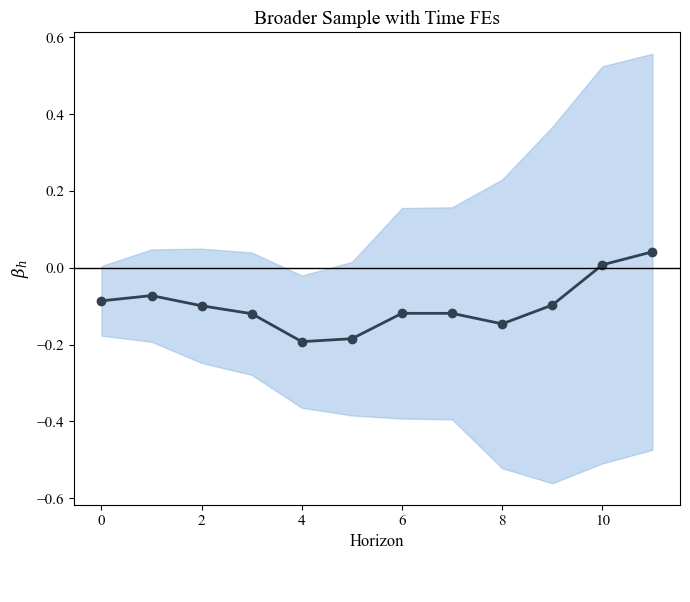

: 

In [ ]:
fig, shock_ax = plt.subplots(figsize=(7, 6))

lp.plot_irf(
    irf_df,
    title=r"CPI response to $\xi_{m,t-4}u_t$",
    ax=shock_ax,
)
if include_time_fe:
    shock_ax.set_ylabel(r"$\beta_h$", fontfamily="serif", fontsize=12)
    shock_ax.set_title(r"Broader Sample with Time FEs", fontfamily="serif", fontsize=14)
    fig.text(
    0.05, 0.01,
    ' ',
    ha='left',
    fontsize=10,
    color='black',
    fontfamily='serif',
    )
else:
    shock_ax.set_ylabel(r"$\beta_h$", fontfamily="serif", fontsize=12)
    shock_ax.set_title(r"Broader Sample without Time FEs", fontfamily="serif", fontsize=14)
    fig.text(
    0.05, 0.01,
    r'Notes: The shaded area represents the 95% confidence interval.',
    ha='left',
    fontsize=10,
    color='black',
    fontfamily='serif',
    )
shock_ax.set_xlabel("Horizon", fontfamily="serif", fontsize=12)


plt.tight_layout(rect=[0, 0.05, 1, 1])
#plt.savefig(f'irf_{naming}_broad.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [34]:
horizon_to_inspect = 4
print(models[horizon_to_inspect].summary())

                            OLS Regression Results                            
Dep. Variable:          cum_cpi_lead4   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     480.9
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.78e-55
Time:                        22:20:08   Log-Likelihood:                 9300.1
No. Observations:                3531   AIC:                        -1.828e+04
Df Residuals:                    3372   BIC:                        -1.730e+04
Df Model:                         158                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.4020    

c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
